In [ ]:
import numpy as np
import random
from sklearn.metrics import confusion_matrix

# Traitement
from src.donnees import import_donnees, renomer_cle_jointure, concatenation_annees
from src.nettoyage import recodage, mapping_renommer_colonnes, colonnes_a_supprimer, création_age_usager, jointure, creation_mois_num, rajout_colonnes

# Modelisation
from src.fct_modelisation import y_x_train_test, importance_variable, importance_variable_gravite
from src.fct_sortie_propre import pretty_report, matrice_confusion, pretty_importances, pretty_importance_gravite

In [65]:
import importlib
import src.fct_modelisation

importlib.reload(src.fct_modelisation)

import src.fct_sortie_propre

importlib.reload(src.fct_sortie_propre)


<module 'src.fct_sortie_propre' from '/home/onyxia/work/Projet_pythonDS/src/fct_sortie_propre.py'>

In [5]:
donnees_completes = import_donnees()

donnees_completes["caract"][22] = renomer_cle_jointure(donnees_completes["caract"][22], "Num_Acc", "Accident_Id")

# CARACTERISTIQUE
df_caract = concatenation_annees(donnees_completes, "caract")
df_caract = creation_mois_num(df_caract)
# LIEUX
df_lieux = concatenation_annees(donnees_completes, "lieux")
# VEHICULE
df_vehicule = concatenation_annees(donnees_completes, "vehicule")
# USAGER
df_usager = concatenation_annees(donnees_completes, "usager")
mappings = mapping_renommer_colonnes()

# recodage des noms des colonnes 
df_caract_recoder = recodage(df_caract, mappings["caract"])
df_lieux_recoder = recodage(df_lieux, mappings["lieux"])
df_vehicule_recoder = recodage(df_vehicule, mappings["vehicule"])
df_usager_recoder = recodage(df_usager, mappings["usager"])

# supprimer les doublons de corrections des données dans le fichier lieux 
df_lieux_recoder = df_lieux_recoder.drop_duplicates(subset="Num_Acc", keep="last")

# age pour les usagers
df_usager_recoder = création_age_usager(df_usager_recoder)
df_final = jointure(df_caract_recoder, df_lieux_recoder, df_vehicule_recoder, df_usager_recoder)
colonnes_a_supprimer = colonnes_a_supprimer()
df_final = df_final.drop(columns=colonnes_a_supprimer, errors="ignore")
df_final = df_final.dropna(subset=["id_usager"])
df_final = rajout_colonnes(df_final)

# suppression des NA 
df_final = df_final.dropna(subset=["lum", "int", "atm", "col", "prof", "plan", "surf", "situ", "catv", "obs", "obsm", "choc", "sexe", "age", "secu1"])

/home/onyxia/work/Projet_pythonDS/src/donnees.py:8: DtypeWarning: Columns (0: lartpc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')
/home/onyxia/work/Projet_pythonDS/src/donnees.py:8: DtypeWarning: Columns (0: nbv) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')


# Modelisation :
Nous nous interressons à la prédiction de la gravité des blessures des usagers d'un accident de la route. Pour ce faire nous allons étudier :
- la variable de gravité (variables catégorielle à expliquer) : 1 = Indemne, 2 = Blessé léger, 3 = Blessé hospitalisé, 4 = Tué
- un Random Forest, nous permettant de classifier nos données
- des facteurs clés pour classifier la gravité d'accidents : choc avant / arrière / latéral, âge de l'usager, sexe, port de la ceinture / casque, luminosité, état de la chaussée, type de route (autoroute, nationale, départementale), zone (urbaine / rurale), département, heure, jour de la semaine ...

Les valeurs manquantes des variables que nous allons utiliser s'y après ont déjà été géré (c'est à dire supprimé) dans la première phase de ce projet. Les variables comportant encore des valeurs NA dans nos données ne seront pas utilisé pour les modèles

## III - Classification de la gravité d'un accident par un Random Forest

In [6]:
# Graine de reproductibilité
np.random.seed(66)
random.seed(66)

In [7]:
# Codage de la variable cible en numérique
grav_dict = {
    "Indemne":1,
    "Blessé léger":2,
    "Blessé hospitalisé":3,
    "Tué":4,
}
df_final = recodage(df_final, {"grav": grav_dict})

### Encodage des variables explicatives 

Nous identifions les variables les plus pertinantes pour notre analyses. Pour l'heure nous faisons un regroupement en fonction des heures : Nuit (00–06), Matin (06–12),Après‑midi (12–18), Soir (18–24). 
Puis nous séparons les valeurs en jeux d'entrainemtn et de tests, sans oublier de coder les variables catégorielles. (toute sauf l'âge)

In [71]:
# Séparation du jeu de donnée en y et X puis en jeu d'entrainement et de test en passant par l'encodage
# suppression NA de manv
df_final = df_final.dropna(subset=["manv"])
X_train, X_test, y_train, y_test = y_x_train_test(df_final, "grav", ["mois", "an", "lum", "dep", "agg", "int", "surf", "catv", "obs","obsm",
                                                                     "choc", "sexe", "situ", "secu1", "age", "atm", "col", "catr", "prof",
                                                                     "plan", "manv", "catu", "jour_semaine"])

In [72]:
X_train

,age,mois_avril,mois_décembre,mois_février,mois_janvier,mois_juillet,mois_juin,mois_mai,mois_mars,mois_novembre,...,catu_Piéton,jour_semaine_Jeudi,jour_semaine_Lundi,jour_semaine_Mardi,jour_semaine_Mercredi,jour_semaine_Samedi,jour_semaine_Vendredi,heure_cat_Matin,heure_cat_Après-midi,heure_cat_Soir
266416,88,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
243223,21,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
328170,24,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False
182252,86,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
193774,56,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45987,48,True,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
295701,60,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
181181,32,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
112621,75,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


### Entrainement du modèle 

Les classes de gravité "Tué" sont moins nombreuses que les autres, mais comme on veut classifier correctement les classes et notamment celle-ci car il est important de pouvoir identifier les accidents avec une gravités élevé, il nous faut donc attribuer des poids aux classes.

In [37]:
from sklearn.ensemble import RandomForestClassifier

poids = {
    "1": 1,   # indemne
    "2": 1.07,   # blessé léger
    "3": 2.77,   # blessé hospitalisé
    "4": 15.4   # tué
}

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=poids,
    random_state=66,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluation et importance des facteurs 

In [38]:
y_pred = rf.predict(X_test)

pretty_report(y_test, y_pred)


,precision,recall,f1-score,support
1,0.742,0.826,0.781,30322
2,0.702,0.572,0.630,29705
3,0.447,0.551,0.494,11455
4,0.319,0.225,0.264,2058
accuracy,0.664,0.664,0.664,73540
macro avg,0.552,0.543,0.542,73540
weighted avg,0.668,0.664,0.661,73540


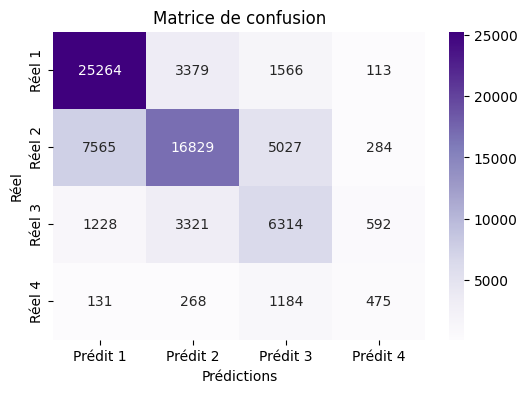

In [36]:
cm = confusion_matrix(y_test, y_pred)
matrice_confusion(cm)

Les classes 1 et 2 sont bien prédites, pour les classes 3 et 4 bcp moins de bonnes prédictions, cela est du au fait que les données comporte moins d'accidnet comportant ces gravités de blessures, le 3 et 4 sont tué et blessures hospitalisé. Surtout au niveau des "Tué", le modele ne retrouve de 0.225 bonne valeurs, ce qui est plutot faible. Même si le modèle a une accuracy globale correct de 66%, nous voulons notamment prédire les tués pour voir ce qui est le plus dangereux, donc ici notre modèle n'est pas le plus performant. 

In [22]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=400,
    sampling_strategy="auto",
    random_state=66,
    n_jobs=-1
)

brf.fit(X_train, y_train)


,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [44]:
y_pred_brf = brf.predict(X_test)
pretty_report(y_test, y_pred_brf)

,precision,recall,f1-score,support
1,0.733,0.821,0.775,30322
2,0.734,0.466,0.570,29705
3,0.411,0.375,0.392,11455
4,0.143,0.716,0.239,2058
accuracy,0.605,0.605,0.605,73540
macro avg,0.505,0.594,0.494,73540
weighted avg,0.667,0.605,0.617,73540


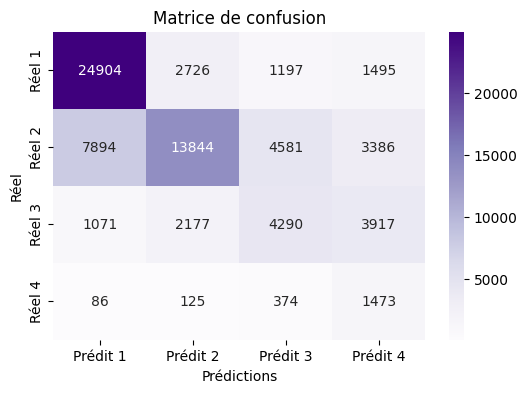

In [45]:
cm = confusion_matrix(y_test, y_pred_brf)
matrice_confusion(cm)

Ce modèle détecte nettement mieux les classes rares, en revanche, il y a aussi une baisse de la présicion car le modèle se trompe plus souvent quand il classifie en accident "Tué". 

### GridSearchCV - tentative d'amélioration du modèle avec l'optimisation des paramètres


In [ ]:
param_grid = {
    "n_estimators": [100],   
    "max_depth": [None, 12, 20], 
    "class_weight": [
        {"1":1, "2":1, "3":2, "4":6},
        {"1":1, "2":1, "3":3, "4":15},
        "balanced_subsample"
    ]
}

In [43]:
from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(
    random_state=66,
    n_jobs=1
)

grid = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="recall_macro",
    refit="recall_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END class_weight={'1': 1, '2': 1, '3': 2, '4': 6}, max_depth=12, n_estimators=100; total time=  31.8s
[CV] END class_weight={'1': 1, '2': 1, '3': 2, '4': 6}, max_depth=12, n_estimators=100; total time=  31.7s
[CV] END class_weight={'1': 1, '2': 1, '3': 2, '4': 6}, max_depth=12, n_estimators=100; total time=  32.0s
[CV] END class_weight={'1': 1, '2': 1, '3': 3, '4': 15}, max_depth=12, n_estimators=100; total time=  31.6s
[CV] END class_weight={'1': 1, '2': 1, '3': 3, '4': 15}, max_depth=12, n_estimators=100; total time=  32.2s
[CV] END class_weight={'1': 1, '2': 1, '3': 3, '4': 15}, max_depth=12, n_estimators=100; total time=  33.1s
[CV] END class_weight={'1': 1, '2': 1, '3': 2, '4': 6}, max_depth=20, n_estimators=100; total time=  54.2s
[CV] END class_weight={'1': 1, '2': 1, '3': 2, '4': 6}, max_depth=20, n_estimators=100; total time=  55.4s
[CV] END class_weight={'1': 1, '2': 1, '3': 2, '4': 6}, max_depth=20, n_estimator

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=66)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{'1': 1, '2': 1, '3': 2, '4': 6}, {'1': 1, '2': 1, '3': 3, '4': 15}, ...], 'max_depth': [None, 12, ...], 'n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [46]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleurs score :", grid.best_score_)


Meilleurs paramètres : {'class_weight': 'balanced_subsample', 'max_depth': 12, 'n_estimators': 100}
Meilleurs score : 0.5555034722799532


Selon la gridsearch les meilleurs parametres sont ci-dessus. Nous allons donc refaire un modele avce les paramètres.

on peut égalemtn tester avce plus d'arbres car avec la grid search trop d'arbre prennet trop de ressources donc compliqué par contre nous allons mettre un peu plus d'arbre car a chaque fois, les différentes gridsearch choisisse le plus grand nombre d'arbre disponible 

on remarque que les tué sont bien trouvé en revanche certains non tué sont predit en tué 

In [47]:
rf_opti = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=66,
    n_jobs=-1
)

rf_opti.fit(X_train, y_train)

y_pred = rf_opti.predict(X_test)
pretty_report(y_test, y_pred)


,precision,recall,f1-score,support
1,0.671,0.871,0.758,30322
2,0.749,0.370,0.495,29705
3,0.400,0.360,0.379,11455
4,0.144,0.639,0.234,2058
accuracy,0.583,0.583,0.583,73540
macro avg,0.491,0.560,0.467,73540
weighted avg,0.645,0.583,0.578,73540


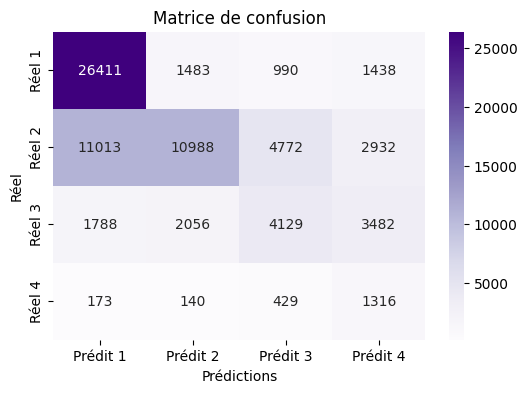

In [48]:
cm = confusion_matrix(y_test, y_pred)
matrice_confusion(cm)

En optimisant, les paramètres et en utilisant le scoring "recall_macro", notre modèle détecte bien les accidents "Tué". Mais la précision est en baisse. 
Pour analyser l'importance des variables, nous allons choisir le modèle réalisé avec balancedRandomForest qui est meilleur pour la détéction des classes rares que notre modèle réalisé avec gridsearch. En revanche, ce modèle est moins bon globalement que le premier modèle RandomForest que nous avons effectuer. Cepdnant comme nous voulons identifier les gravités (sans manquer les classes les plus rares), nous garderons celui-ci.

In [51]:
import numpy as np
pretty_importances(importance_variable(brf, X_train))

,variable,importance
0,age,0.0720
204,secu1_Ceinture,0.0304
124,agg_Hors agglomération,0.0194
201,secu1_Aucun équipement,0.0146
194,sexe_Homme,0.0145
175,obs_Sans objet,0.0143
203,secu1_Casque,0.0138
12,an_2023,0.0138
13,an_2024,0.0137
159,catv_VL,0.0130


In [69]:
# Corrélation entre variables et probabilité de la gravité "Tué"
pretty_importance_gravite(importance_variable_gravite(brf, X_test, 3))

,variable,corr,abs_corr
180,obsm_Aucun,0.4343,0.4343
175,obs_Sans objet,-0.4104,0.4104
195,situ_Sur accotement,0.3732,0.3732
124,agg_Hors agglomération,0.3656,0.3656
183,obsm_Véhicule,-0.3402,0.3402
198,situ_Sur chaussée,-0.3200,0.3200
204,secu1_Ceinture,-0.3193,0.3193
201,secu1_Aucun équipement,0.2868,0.2868
244,manv_Déporté,0.2851,0.2851
228,catr_Route départementale,0.2750,0.2750


In [67]:
# Corrélation entre variables et probabilité de la gravité "Indemne"
pretty_importance_gravite(importance_variable_gravite(brf, X_test, 0))

,variable,corr,abs_corr
204,secu1_Ceinture,0.6301,0.6301
203,secu1_Casque,-0.4645,0.4645
159,catv_VL,0.3537,0.3537
201,secu1_Aucun équipement,-0.3373,0.3373
180,obsm_Aucun,-0.3228,0.3228
150,catv_Motocyclette,-0.3170,0.3170
175,obs_Sans objet,0.3055,0.3055
260,catu_Piéton,-0.3013,0.3013
257,manv_Tournant,0.2352,0.2352
221,col_Sans collision,-0.2118,0.2118


In [68]:
# Corrélation entre variables et probabilité de la gravité "Bléssé léger"
pretty_importance_gravite(importance_variable_gravite(brf, X_test, 1))

,variable,corr,abs_corr
204,secu1_Ceinture,-0.2954,0.2954
0,age,-0.2699,0.2699
228,catr_Route départementale,-0.2698,0.2698
124,agg_Hors agglomération,-0.2404,0.2404
153,catv_Scooter,0.2380,0.2380
92,dep_75,0.2363,0.2363
230,catr_Voie communale,0.2346,0.2346
203,secu1_Casque,0.2289,0.2289
195,situ_Sur accotement,-0.2142,0.2142
183,obsm_Véhicule,0.2131,0.2131


In [70]:
# Corrélation entre variables et probabilité de la gravité "Bléssé hospitalisé"
pretty_importance_gravite(importance_variable_gravite(brf, X_test, 2))

,variable,corr,abs_corr
204,secu1_Ceinture,-0.5533,0.5533
203,secu1_Casque,0.5097,0.5097
150,catv_Motocyclette,0.3741,0.3741
159,catv_VL,-0.3499,0.3499
180,obsm_Aucun,0.2876,0.2876
228,catr_Route départementale,0.2612,0.2612
145,catv_Cyclomoteur,0.2596,0.2596
201,secu1_Aucun équipement,0.2550,0.2550
175,obs_Sans objet,-0.2387,0.2387
221,col_Sans collision,0.2306,0.2306


On observe donc plusiuers variables qui sont corrélés au fait d'avoir des blessures plus grave que d'autres :
- le port de la ceinture de sécurité : une corrélation de -0.32 pour les "Tué" et pour aucun_équipement 0.2868 - le fait de ne pas avoir d'équipement de sécurité favorise le fait d'avoir des accidents grave (c'est l'inverse pour les "Indemne")
- le type de route, hors agglomération et route départementale favorise un accident à haut risque
- la catégorie de véhicule : les véhicule lourds (VL) plus de risque de blessures lègéres.
